In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [13]:
# ==================== Configuration ====================
class Config:
    """Configuration class for model hyperparameters"""
    # Network architecture
    hidden_layers = [32, 16, 8]

    # Training parameters
    learning_rate = 0.001
    batch_size = 1024
    epochs = 100
    early_stopping_rounds = 10
    n_ensembles = 10

    # Data parameters
    initial_train_years = 3
    validation_years = 1
    test_months = 1

    # Lag candidates
    lag_candidates = [1, 5, 16, 22, 32, 44, 66, 88, 132, 252]

    # Device
    #if torch.backends.mps.is_available(): #mps sucks...
        #device = torch.device("mps")
       # print("Using MPS")
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print("Using CUDA")
    else:
        device = torch.device('cpu')
        print("Using CPU")


Using CPU


In [14]:
# ==================== Neural Network Model ====================
class MLPWithBatchNorm(nn.Module):
    """MLP with Batch Normalization"""
    def __init__(self, input_dim, hidden_layers):
        super(MLPWithBatchNorm, self).__init__()

        layers = []
        prev_dim = input_dim

        # Build hidden layers with batch normalization
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))  # Adding dropout for regularization
            prev_dim = hidden_dim

        # Output layer
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [15]:
# ==================== Data Preparation Functions ====================
def load_and_prepare_data(filepath='SPY.csv'):
    """Load and prepare the realized volatility data"""
    rv = pd.read_csv(filepath)
    rv = rv[["Date", "Volatility", "Type"]]
    rv.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    rv = rv[rv['Type'] == 'QMLE-Trade']
    rv.drop(columns=['Type'], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"

    print(f"Data loaded: {len(rv)} observations")
    print(f"Date range: {rv.index.min()} to {rv.index.max()}")

    return rv

def create_lagged_features(data, lags):
    """Create lagged features for the model"""
    df = data.copy()

    # Create lagged features
    for lag in lags:
        df[f'lag_{lag}'] = df['RV_daily'].shift(lag)

    # Remove rows with NaN values (from lagging)
    df = df.dropna()

    return df

def prepare_train_val_test_data(df, train_start, train_end, val_end, test_end):
    """Split data into train, validation, and test sets"""
    train_data = df[train_start:train_end]
    val_data = df[train_end:val_end]
    test_data = df[val_end:test_end]

    return train_data, val_data, test_data

In [16]:
# ==================== Model Training Functions ====================
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def train_single_model(X_train, y_train, X_val, y_val, config, verbose=False):
    """Train a single MLP model"""
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(config.device)
    y_train_tensor = torch.FloatTensor(y_train).to(config.device)
    X_val_tensor = torch.FloatTensor(X_val).to(config.device)
    y_val_tensor = torch.FloatTensor(y_val).to(config.device)

    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

    # Initialize model
    model = MLPWithBatchNorm(X_train.shape[1], config.hidden_layers).to(config.device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

    # Early stopping
    early_stopping = EarlyStopping(patience=config.early_stopping_rounds)

    # Training loop
    train_losses = []
    val_losses = []

    for epoch in range(config.epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor).item()
            val_losses.append(val_loss)

        # Early stopping check
        early_stopping(val_loss)
        if early_stopping.early_stop:
            if verbose:
                print(f"Early stopping triggered at epoch {epoch+1}")
            break

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{config.epochs}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model, train_losses, val_losses

def train_ensemble(X_train, y_train, X_val, y_val, config):
    """Train an ensemble of models"""
    models = []

    print(f"Training ensemble of {config.n_ensembles} models...")
    for i in range(config.n_ensembles):
        print(f"Training model {i+1}/{config.n_ensembles}")
        model, _, _ = train_single_model(X_train, y_train, X_val, y_val, config, verbose=False)
        models.append(model)

    return models

def predict_ensemble(models, X, config):
    """Make predictions using ensemble of models"""
    X_tensor = torch.FloatTensor(X).to(config.device)
    predictions = []

    for model in models:
        model.eval()
        with torch.no_grad():
            pred = model(X_tensor).cpu().numpy()
            predictions.append(pred)

    # Average predictions
    ensemble_pred = np.mean(predictions, axis=0)
    return ensemble_pred

In [17]:
# ==================== Evaluation Functions ====================
def calculate_mse(y_true, y_pred):
    """Calculate Mean Squared Error"""
    return mean_squared_error(y_true, y_pred)

def calculate_qlike(y_true, y_pred):
    """Calculate QLIKE loss"""
    # Avoid division by zero
    y_pred = np.maximum(y_pred, 1e-8)
    return np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)

In [18]:
# Calculate Information Criteria

#def calculate_BIC():


In [19]:
# ==================== Expanding Window Implementation ====================
def expanding_window_forecast(rv_data, config):
    """Implement expanding window forecasting"""
    # Create lagged features
    df_with_lags = create_lagged_features(rv_data, config.lag_candidates)

    # Initialize results storage
    all_results = []

    # Get feature columns
    feature_cols = [col for col in df_with_lags.columns if col.startswith('lag_')]

    # Start date for expanding window
    start_date = df_with_lags.index[0]
    initial_train_end = start_date + pd.DateOffset(years=config.initial_train_years)

    # Find the first valid test start date
    current_test_start = initial_train_end + pd.DateOffset(years=config.validation_years)

    print(f"\nStarting expanding window forecasting...")
    print(f"Initial training period: {start_date.date()} to {initial_train_end.date()}")

    window_count = 0

    while current_test_start < df_with_lags.index[-1]:
        window_count += 1

        # Define periods
        train_end = current_test_start - pd.DateOffset(years=config.validation_years)
        val_start = train_end
        val_end = current_test_start
        test_end = min(current_test_start + pd.DateOffset(months=config.test_months),
                       df_with_lags.index[-1])

        # Get data splits
        train_data = df_with_lags[start_date:train_end]
        val_data = df_with_lags[val_start:val_end]
        test_data = df_with_lags[val_end:test_end]

        if len(test_data) == 0:
            break

        print(f"\n--- Window {window_count} ---")
        print(f"Train: {start_date.date()} to {train_end.date()} ({len(train_data)} obs)")
        print(f"Val: {val_start.date()} to {val_end.date()} ({len(val_data)} obs)")
        print(f"Test: {val_end.date()} to {test_end.date()} ({len(test_data)} obs)")

        # Prepare features and targets
        X_train = train_data[feature_cols].values
        y_train = train_data['RV_daily'].values.reshape(-1, 1)
        X_val = val_data[feature_cols].values
        y_val = val_data['RV_daily'].values.reshape(-1, 1)
        X_test = test_data[feature_cols].values
        y_test = test_data['RV_daily'].values.reshape(-1, 1)

        #

        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test)

        # Train ensemble
        models = train_ensemble(X_train_scaled, y_train, X_val_scaled, y_val, config)

        # Make predictions
        train_pred = predict_ensemble(models, X_train_scaled, config)
        test_pred = predict_ensemble(models, X_test_scaled, config)

        # Calculate metrics
        train_mse = calculate_mse(y_train, train_pred)
        test_mse = calculate_mse(y_test, test_pred)
        train_qlike = calculate_qlike(y_train, train_pred)
        test_qlike = calculate_qlike(y_test, test_pred)

        print(f"In-sample MSE: {train_mse:.6f}, QLIKE: {train_qlike:.6f}")
        print(f"Out-of-sample MSE: {test_mse:.6f}, QLIKE: {test_qlike:.6f}")

        # Store results
        for i, date in enumerate(test_data.index):
            all_results.append({
                'ticker': 'SPY',
                'date': date,
                'real_RV': y_test[i, 0],
                'predicted_RV': test_pred[i, 0],
                'window': window_count,
                'train_mse': train_mse,
                'test_mse': test_mse,
                'train_qlike': train_qlike,
                'test_qlike': test_qlike
            })

        # Move to next window (1 month forward)
        current_test_start = current_test_start + pd.DateOffset(months=1)

    return pd.DataFrame(all_results)

In [20]:
# ==================== Visualization Functions ====================
def plot_results(results_df):
    """Plot actual vs predicted RV values"""
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Time series of actual vs predicted
    ax1 = axes[0]
    ax1.plot(results_df['date'], results_df['real_RV'], label='Actual RV', alpha=0.7, linewidth=1)
    ax1.plot(results_df['date'], results_df['predicted_RV'], label='Predicted RV', alpha=0.7, linewidth=1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Realized Volatility')
    ax1.set_title('MLP Neural Network: Actual vs Predicted Realized Volatility')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Scatter plot
    ax2 = axes[1]
    ax2.scatter(results_df['real_RV'], results_df['predicted_RV'], alpha=0.5, s=10)

    # Add diagonal line
    min_val = min(results_df['real_RV'].min(), results_df['predicted_RV'].min())
    max_val = max(results_df['real_RV'].max(), results_df['predicted_RV'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Perfect Prediction')

    ax2.set_xlabel('Actual RV')
    ax2.set_ylabel('Predicted RV')
    ax2.set_title('Actual vs Predicted RV (Scatter Plot)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('mlp_rv_forecast_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_summary_statistics(results_df):
    """Print summary statistics of the forecasting results"""
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    # Overall metrics
    overall_mse = calculate_mse(results_df['real_RV'], results_df['predicted_RV'])
    overall_qlike = calculate_qlike(results_df['real_RV'].values, results_df['predicted_RV'].values)

    print(f"\nOverall Out-of-Sample Performance:")
    print(f"MSE: {overall_mse:.6f}")
    print(f"QLIKE: {overall_qlike:.6f}")

    # Average metrics across windows
    avg_train_mse = results_df.groupby('window')['train_mse'].first().mean()
    avg_test_mse = results_df.groupby('window')['test_mse'].first().mean()
    avg_train_qlike = results_df.groupby('window')['train_qlike'].first().mean()
    avg_test_qlike = results_df.groupby('window')['test_qlike'].first().mean()

    print(f"\nAverage Performance Across Windows:")
    print(f"In-Sample - MSE: {avg_train_mse:.6f}, QLIKE: {avg_train_qlike:.6f}")
    print(f"Out-of-Sample - MSE: {avg_test_mse:.6f}, QLIKE: {avg_test_qlike:.6f}")

    # Correlation
    correlation = results_df['real_RV'].corr(results_df['predicted_RV'])
    print(f"\nCorrelation between Actual and Predicted: {correlation:.4f}")

    # Number of windows
    n_windows = results_df['window'].nunique()
    print(f"\nTotal number of expanding windows: {n_windows}")
    print(f"Total predictions made: {len(results_df)}")

MLP NEURAL NETWORK FOR REALIZED VOLATILITY FORECASTING

Using device: cpu

Loading data...
Data loaded: 7301 observations
Date range: 1996-01-02 00:00:00 to 2025-04-29 00:00:00

Starting expanding window forecasting...
Initial training period: 1996-12-31 to 1999-12-31

--- Window 1 ---
Train: 1996-12-31 to 1999-12-31 (758 obs)
Val: 1999-12-31 to 2000-12-31 (253 obs)
Test: 2000-12-31 to 2001-01-31 (21 obs)
Training ensemble of 10 models...
Training model 1/10
Training model 2/10
Training model 3/10
Training model 4/10
Training model 5/10
Training model 6/10
Training model 7/10
Training model 8/10
Training model 9/10
Training model 10/10
In-sample MSE: 0.010094, QLIKE: 0.244254
Out-of-sample MSE: 0.026003, QLIKE: 0.348994

--- Window 2 ---
Train: 1996-12-31 to 2000-01-31 (778 obs)
Val: 2000-01-31 to 2001-01-31 (254 obs)
Test: 2001-01-31 to 2001-02-28 (20 obs)
Training ensemble of 10 models...
Training model 1/10
Training model 2/10
Training model 3/10
Training model 4/10
Training model 5

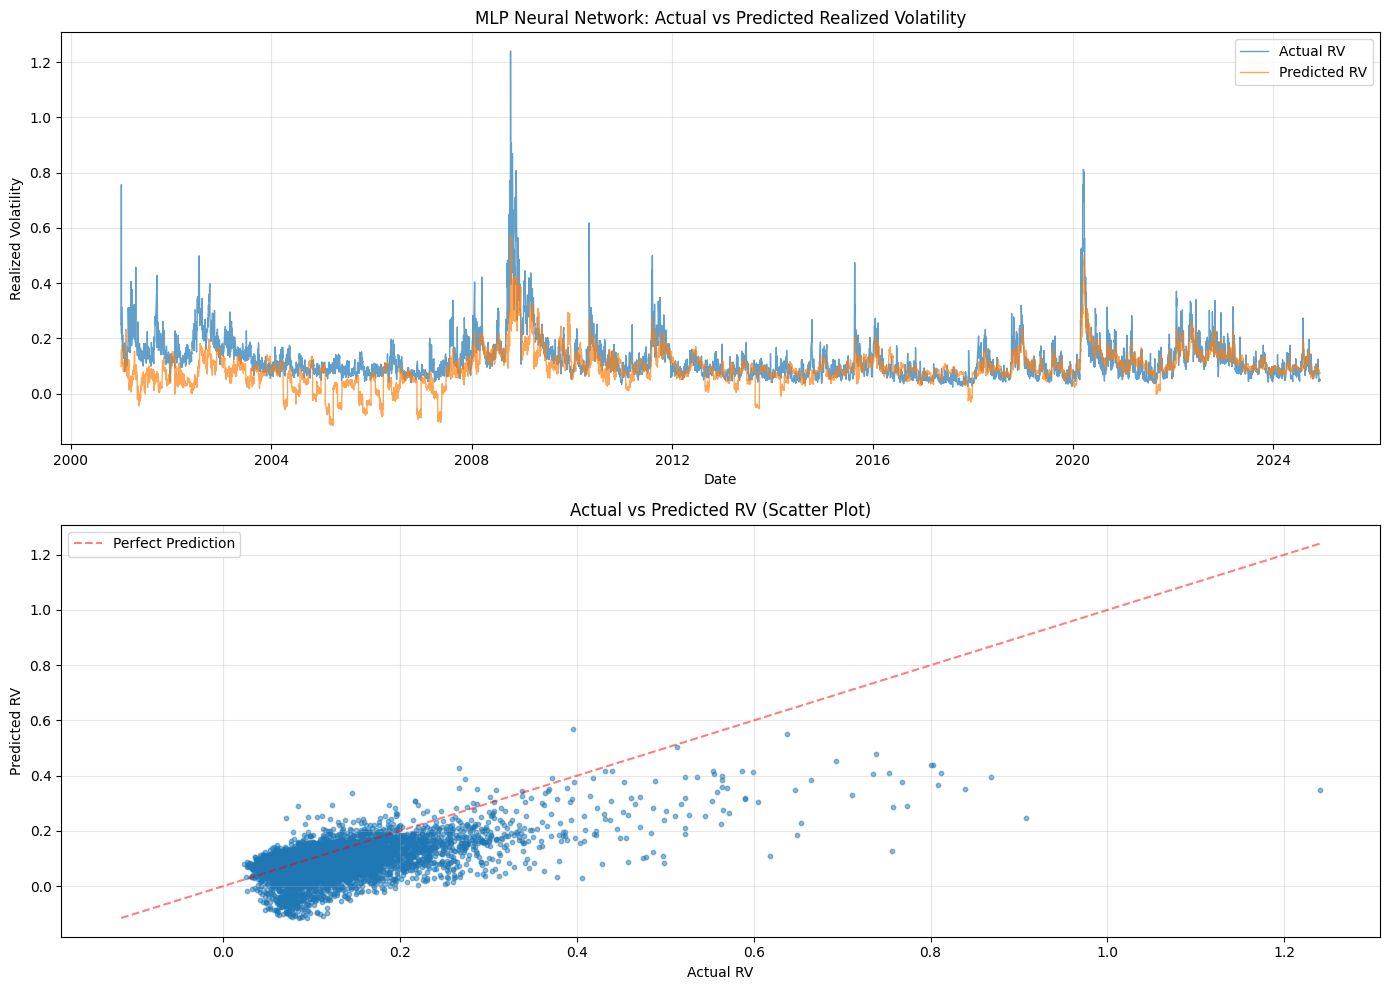


FORECASTING COMPLETED SUCCESSFULLY


In [21]:
# ==================== Main Execution ====================
def main():
    """Main execution function"""
    print("="*60)
    print("MLP NEURAL NETWORK FOR REALIZED VOLATILITY FORECASTING")
    print("="*60)

    # Initialize configuration
    config = Config()
    print(f"\nUsing device: {config.device}")

    # Load data
    print("\nLoading data...")
    rv_data = load_and_prepare_data('SPY.csv')

    # Run expanding window forecast
    results_df = expanding_window_forecast(rv_data, config)

    # Save results
    output_filename = 'mlp_rv_forecast_results.csv'
    results_df.to_csv(output_filename, index=False)
    print(f"\nResults saved to {output_filename}")

    # Print summary statistics
    print_summary_statistics(results_df)

    # Plot results
    print("\nGenerating plots...")
    plot_results(results_df)

if __name__ == "__main__":
    main()